# EMT and DP Ph3 GFL state-space validation

This notebook presents the concise validation results; complete spectra and benchmark-selection diagnostics are kept in `EMT_DP_Ph3_GFL_StateSpaceValidation_Diagnostics.ipynb`.

The benchmark represents a 3.3 kV, 12 MVA grid-following converter connected to an external Thevenin network referred to the converter terminals. The nominal operating point is $P=0.8$ pu, $Q=0.1$ pu, with SCR 2.5 and $X/R=10$. Transformer and upstream-network impedance are aggregated into the Thevenin branch; no transformer dynamics are modeled.

The controller structure is unchanged. Study 3 varies **only the proportional gain of the outer power loop**, $K_{p,P}$; PLL, integral, and current-controller gains remain fixed.

Four DPsim realizations are compared: EMT variable, EMT split, DP Ph3 variable, and DP Ph3 split. Variable formulations use a separately assembled, component-wise no-delay $dq0$ reference. Split formulations use an exact component-wise companion reference containing the same one-sample bridge-voltage delay.

Run from the CMake output directory:

```bash
cmake --build build --target EMT_DP_Ph3_GFL_StateSpaceValidation
cd build/dpsim/examples/cxx
./EMT_DP_Ph3_GFL_StateSpaceValidation --time-domain
```


In [26]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

build_dir = Path("/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx")
result_dir = build_dir / "logs/EMT_DP_Ph3_GFL_StateSpaceValidation"
required = ["parameters.csv", "eigenvalues.csv", "summary.csv", "participation.csv"]
missing = [name for name in required if not (result_dir / name).exists()]
if missing:
    raise FileNotFoundError(f"Missing {missing} in {result_dir}. Run the C++ example first.")

parameters = pd.read_csv(result_dir / "parameters.csv")
eigenvalues = pd.read_csv(result_dir / "eigenvalues.csv")
summary = pd.read_csv(result_dir / "summary.csv")
participation = pd.read_csv(result_dir / "participation.csv")
manifest_path = result_dir / "time_domain_manifest.csv"
time_manifest = pd.read_csv(manifest_path) if manifest_path.exists() else pd.DataFrame()
parameter_table = parameters.set_index("parameter")

def display_numeric_table(frame, precision=5):
    shown = frame.copy()
    numeric = shown.select_dtypes(include=[np.number]).columns
    shown.loc[:, numeric] = shown.loc[:, numeric].round(precision)
    display(shown)

model_order = ["analytical no delay", "exact split companion", "EMT variable",
               "EMT split", "DP Ph3 variable", "DP Ph3 split"]
colors = dict(zip(model_order, plt.get_cmap("tab10").colors))
markers = {"analytical no delay": "x", "exact split companion": "+",
           "EMT variable": "o", "EMT split": "s",
           "DP Ph3 variable": "^", "DP Ph3 split": "v"}
reference_models = {"analytical no delay", "exact split companion"}

def modal_method(model):
    return None if model in reference_models else "one_step"

def rows_for(model, dt_us=1.0, study="time_step_sweep", method=None,
             kp_power_multiplier=None):
    rows = eigenvalues[(eigenvalues.model == model)
                       & np.isclose(eigenvalues.time_step_us, dt_us)
                       & (eigenvalues.study == study)]
    if method is not None:
        rows = rows[rows.method == method]
    if kp_power_multiplier is not None:
        rows = rows[np.isclose(rows.kp_power_multiplier, kp_power_multiplier)]
    return rows

def finite_modes(rows, positive=False):
    rows = rows[np.isfinite(rows.lambda_real) & np.isfinite(rows.lambda_imag)].copy()
    return rows[rows.lambda_imag > 0] if positive else rows

def nearest_lambda(rows, target_real, target_imag):
    distance = np.hypot(rows.lambda_real-target_real, rows.lambda_imag-target_imag)
    return rows.loc[distance.idxmin()]

def nearest_z(rows, target):
    distance = np.hypot(rows.z_real-target.z_real, rows.z_imag-target.z_imag)
    return rows.loc[distance.idxmin()]

def mode_near(model, target_hz=112.0, dt_us=1.0, study="time_step_sweep",
              kp_power_multiplier=None, frequency_window=None):
    modes = finite_modes(rows_for(model, dt_us, study, modal_method(model),
                                  kp_power_multiplier), positive=True)
    modes["frequency_hz"] = modes.lambda_imag/(2*np.pi)
    if frequency_window is not None:
        modes = modes[modes.frequency_hz.between(*frequency_window)]
    if modes.empty:
        raise ValueError(f"No candidate mode for {model}, {study}, {dt_us} us")
    return modes.loc[(modes.frequency_hz-target_hz).abs().idxmin()]

def matching_reference(model):
    return "exact split companion" if "split" in model else "analytical no delay"

def lifted_floquet_mode(model, dt_us, reference):
    modes = finite_modes(rows_for(model, dt_us, method="monodromy"))
    omega0 = 2*np.pi*float(parameter_table.loc["frequency", "value"])
    reference_imag = (reference.lambda_imag if "lambda_imag" in reference.index
                      else 2*np.pi*reference.frequency_hz)
    lifted = []
    for row in modes.itertuples():
        k = round((reference_imag-row.lambda_imag)/omega0)
        imag = row.lambda_imag+k*omega0
        lifted.append((np.hypot(row.lambda_real-reference.lambda_real,
                                imag-reference_imag), row, imag))
    if not lifted:
        raise ValueError(f"No Floquet rows for {model} at {dt_us} us")
    _, row, imag = min(lifted, key=lambda item: item[0])
    return row.lambda_real, imag/(2*np.pi)

def mode_indices(model, target_hz=112.0, dt_us=1.0):
    modes = finite_modes(rows_for(model, dt_us, method=modal_method(model)))
    positive = mode_near(model, target_hz, dt_us)
    partner = modes.iloc[np.argmin(abs(modes.lambda_real.to_numpy()-positive.lambda_real)
                                  + abs(modes.lambda_imag.to_numpy()+positive.lambda_imag))]
    return [int(positive["index"]), int(partner["index"])]

def state_group(model, state_index, state_name):
    name = state_name.lower().split(".")[-1]
    controller = ["psi", "theta_pll", "phi_pll", "p_filtered", "q_filtered",
                  "phi_d", "phi_q", "gamma_d", "gamma_q"]
    for label in controller:
        if label == name or name.endswith(label):
            return "psi" if label == "theta_pll" else label
    if "delay" in name: return "v_inv_delay"
    if "u_previous" in name: return "auxiliary interface memory"
    if "gridinductor" in name or "i_line" in name: return "i_line"
    if "vc_" in name or name.startswith("vc"): return "v_c"
    if "if_" in name or name.startswith("if"): return "i_f"
    return state_name

def grouped_participation(model, target_hz=112.0, dt_us=1.0):
    selected = participation[(participation.study == "time_step_sweep")
                             & (participation.model == model)
                             & np.isclose(participation.time_step_us, dt_us)
                             & participation.mode_index.isin(
                                 mode_indices(model, target_hz, dt_us))].copy()
    selected["group"] = [state_group(model, int(i), n)
                         for i, n in zip(selected.state_index, selected.state_name)]
    grouped = selected.groupby("group").p_abs.sum().sort_values(ascending=False)
    return grouped/grouped.sum()

key_parameters = ["voltage_rms_ll", "apparent_power_base",
                  "active_power_reference_pu", "reactive_power_reference_pu",
                  "short_circuit_ratio", "grid_x_over_r",
                  "undamped_lcl_resonance_frequency",
                  "stable_kp_power_multiplier", "unstable_kp_power_multiplier"]
display_numeric_table(parameters[parameters.parameter.isin(key_parameters)])


,parameter,value,unit
1,apparent_power_base,1.200000e+07,VA
2,voltage_rms_ll,3.300000e+03,V
7,active_power_reference_pu,8.000000e-01,pu
8,reactive_power_reference_pu,1.000000e-01,pu
9,short_circuit_ratio,2.500000e+00,-
10,grid_x_over_r,1.000000e+01,-
39,stable_kp_power_multiplier,4.000000e-01,-
40,unstable_kp_power_multiplier,4.500000e-01,-
49,undamped_lcl_resonance_frequency,1.185843e+03,Hz


## Study 1 — small-step modal validation

**Purpose.** At $\Delta t=1\,\mu\mathrm{s}$, validate extracted critical eigenvalues and participation against separately assembled, component-wise reduced references. Variable models are compared with the no-delay reference; split models with the exact delayed companion. Both the complete relevant spectrum and a zoom of the gain-sensitive 112 Hz interaction are shown.


,model/reference,method,matching reference,states,damping [1/s],frequency [Hz],damping error [1/s],frequency error [Hz]
0,analytical no delay,analytical,—,NaN,-16.62937,112.12065,NaN,NaN
1,exact split companion,analytical,—,NaN,-16.56280,112.10510,NaN,NaN
2,EMT variable,one_step,analytical no delay,17.0,-16.62952,112.12067,0.00015,0.00002
3,EMT split,one_step,exact split companion,20.0,-16.55984,112.10448,0.00296,0.00063
4,DP Ph3 variable,one_step,analytical no delay,26.0,-16.62949,112.12067,0.00012,0.00002
5,DP Ph3 split,one_step,exact split companion,32.0,-16.56290,112.10511,0.00010,0.00001
6,EMT variable,Floquet,analytical no delay,17.0,-16.62952,112.12065,0.00015,0.00000
7,EMT split,Floquet,exact split companion,20.0,-16.56120,112.10675,0.00160,0.00165


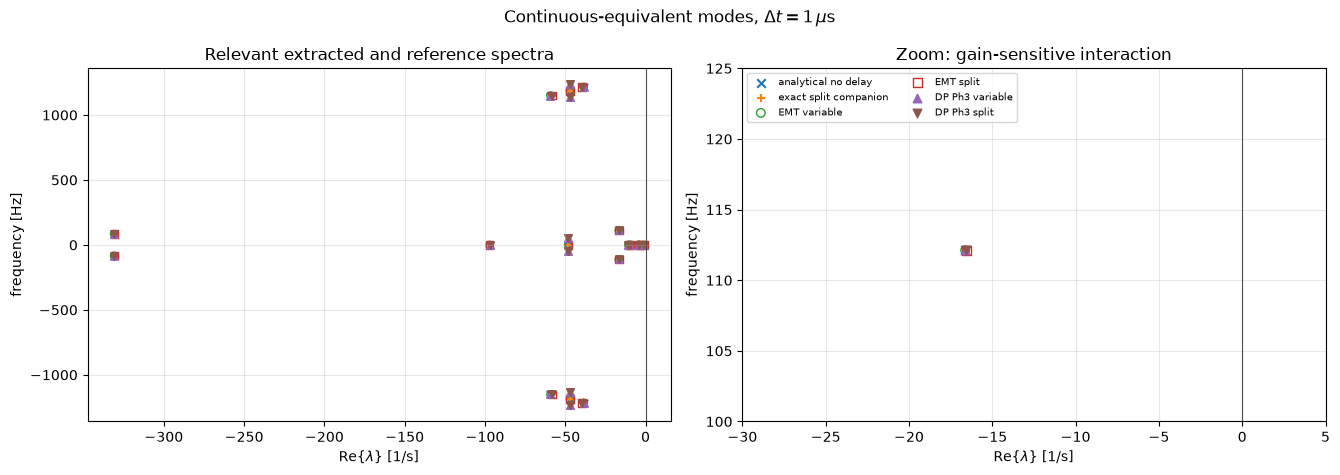

,analytical no delay,EMT variable,DP Ph3 variable,exact split companion,EMT split,DP Ph3 split
group,,,,,,
i_line,0.502,0.502,0.497,0.502,0.502,0.494
q_filtered,0.331,0.331,0.336,0.330,0.330,0.339
p_filtered,0.056,0.056,0.057,0.056,0.056,0.058
psi,0.050,0.050,0.052,0.050,0.050,0.051
i_f,0.049,0.049,0.045,0.049,0.049,0.045
phi_q,0.005,0.005,0.005,0.005,0.005,0.005
v_c,0.004,0.004,0.004,0.004,0.004,0.004


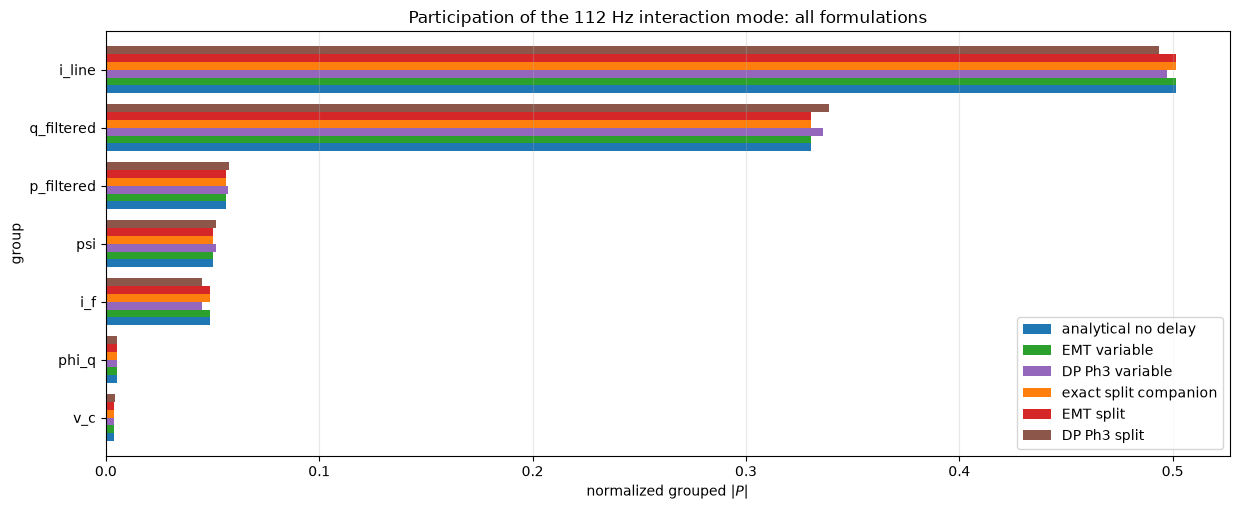

In [27]:
state_count = summary[(summary.study == "time_step_sweep")
                      & np.isclose(summary.time_step_us, 1.0)].set_index("model").state_count.to_dict()
critical_rows = []
for model in model_order:
    mode = mode_near(model)
    ref_name = None if model in reference_models else matching_reference(model)
    ref = mode_near(ref_name) if ref_name else None
    critical_rows.append({"model/reference": model, "method": modal_method(model) or "analytical",
                          "matching reference": ref_name or "—", "states": state_count.get(model, np.nan),
                          "damping [1/s]": mode.lambda_real,
                          "frequency [Hz]": mode.lambda_imag/(2*np.pi),
                          "damping error [1/s]": abs(mode.lambda_real-ref.lambda_real) if ref is not None else np.nan,
                          "frequency error [Hz]": abs(mode.lambda_imag-ref.lambda_imag)/(2*np.pi) if ref is not None else np.nan})
for model in ["EMT variable", "EMT split"]:
    ref_name = matching_reference(model); ref = mode_near(ref_name)
    try:
        damping, frequency = lifted_floquet_mode(model, 1.0, ref)
    except ValueError:
        continue
    critical_rows.append({"model/reference": model, "method": "Floquet",
                          "matching reference": ref_name, "states": state_count.get(model, np.nan),
                          "damping [1/s]": damping, "frequency [Hz]": frequency,
                          "damping error [1/s]": abs(damping-ref.lambda_real),
                          "frequency error [Hz]": abs(frequency-ref.lambda_imag/(2*np.pi))})
display_numeric_table(pd.DataFrame(critical_rows))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for model in model_order:
    modes = finite_modes(rows_for(model, method=modal_method(model)))
    physical = modes[(modes.lambda_real > -2000) & (abs(modes.lambda_imag) < 2*np.pi*2500)]
    axes[0].scatter(physical.lambda_real, physical.lambda_imag/(2*np.pi), marker=markers[model],
                    s=28, facecolors="none" if markers[model] in ["o", "s"] else None,
                    color=colors[model], label=model)
    zoom = physical[(physical.lambda_imag > 0)]
    axes[1].scatter(zoom.lambda_real, zoom.lambda_imag/(2*np.pi), marker=markers[model],
                    s=38, facecolors="none" if markers[model] in ["o", "s"] else None,
                    color=colors[model], label=model)
for ax in axes:
    ax.axvline(0, color="0.3", lw=0.8); ax.grid(alpha=0.3)
    ax.set_xlabel(r"$\mathrm{Re}\{\lambda\}$ [1/s]")
axes[0].set(title="Relevant extracted and reference spectra", ylabel="frequency [Hz]")
axes[1].set(xlim=(-30, 5), ylim=(100, 125), title="Zoom: gain-sensitive interaction",
            ylabel="frequency [Hz]")
axes[1].legend(fontsize=7, ncol=2)
fig.suptitle(r"Continuous-equivalent modes, $\Delta t=1\,\mu$s")
fig.tight_layout(); plt.show()

shown_models = ["analytical no delay", "EMT variable", "DP Ph3 variable",
                "exact split companion", "EMT split", "DP Ph3 split"]
grouped = pd.concat({m: grouped_participation(m) for m in shown_models}, axis=1).fillna(0)
groups = grouped.max(axis=1).nlargest(7).index
display_numeric_table(grouped.loc[groups], precision=3)
grouped.loc[groups].iloc[::-1].plot(kind="barh", figsize=(12.5, 5.2), width=0.82,
                                    color=[colors[m] for m in shown_models])
plt.xlabel(r"normalized grouped $|P|$"); plt.title("Participation of the 112 Hz interaction mode: all formulations")
plt.grid(axis="x", alpha=0.3); plt.tight_layout(); plt.show()


**Study 1 claim.** The extracted models reproduce the damping, frequency, and participating state groups of the separately assembled, component-wise references at small timestep. EMT variable keeps the exact augmented $[x,u_{\mathrm{previous}}]$ recurrence internally, then eliminates its three auxiliary coordinates on the reachable physical subspace for modal analysis. The resulting 17-state modal model agrees with the no-delay reference to approximately $1.5\times10^{-4}\,\mathrm{s^{-1}}$ in damping and $2\times10^{-5}\,\mathrm{Hz}$ in frequency; its Floquet result gives the same conclusion.

## Study 2 — timestep dependence of one corresponding mode

**Purpose.** Follow the same 112 Hz interaction as the timestep increases, comparing every implementation only with its formulation-specific reference. This separates extraction residual from the intentional one-step delay of split formulations. The discrete pole error $|\Delta z|$ is used at coarse steps because it compares the quantity actually executed by the simulation.

The exact split companion is a separately assembled, component-wise **algorithmic reference**: it reconstructs the controller, separately discretized electrical subsystems, algebraic coupling, and one-sample bridge-voltage delay used by the split simulation. Its close agreement with the extracted split model is therefore the intended extraction-validation result. It does not claim that the delayed split formulation is identical to the continuous no-delay physics; that displacement is assessed separately against the no-delay $dq0$ reference. The one-step curves use ordinary round engineering timesteps. Floquet points are shown only when an integer number of steps closes one 50 Hz period, because otherwise the product would end at a different forcing phase and would not be a monodromy matrix. Timesteps from 250 to 1000 µs are included as numerical stress tests rather than representative settings for resolving the converter's approximately 1.2 kHz electrical dynamics.


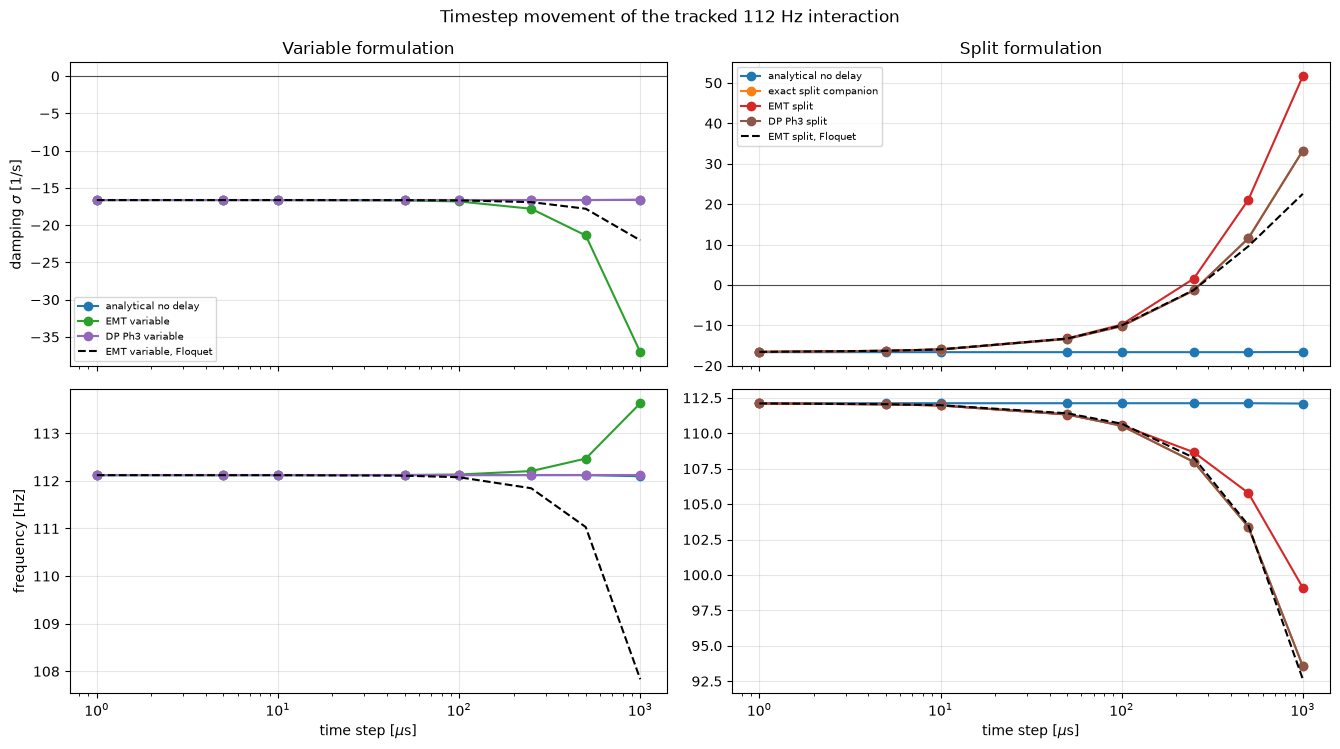

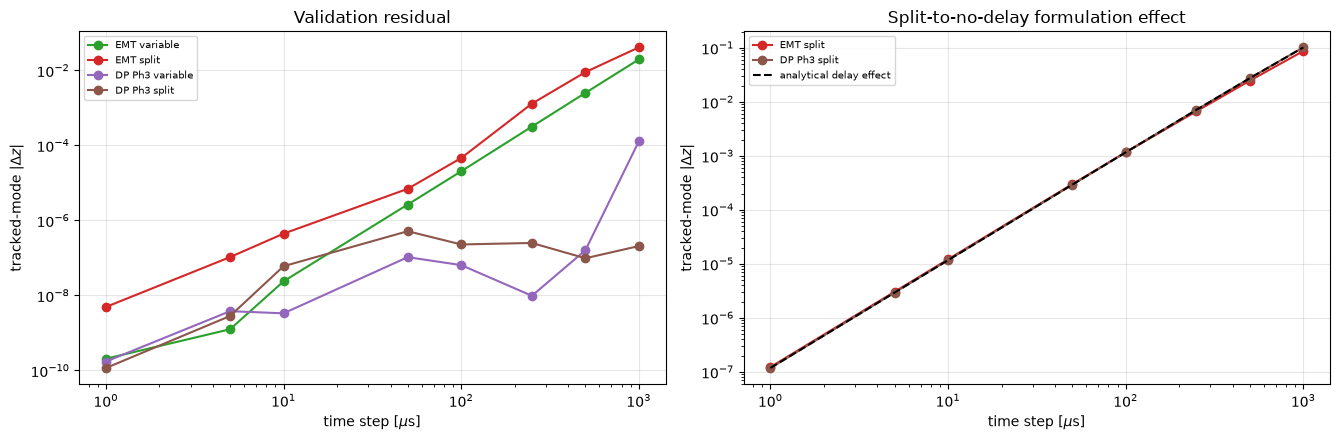

In [28]:
def track_gain_mode(maximum_dt_us=1000.0):
    baseline = mode_near("analytical no delay")
    records = []
    steps = sorted(eigenvalues.loc[(eigenvalues.study == "time_step_sweep")
                                   & (eigenvalues.time_step_us <= maximum_dt_us),
                                   "time_step_us"].unique())
    for dt in steps:
        no_delay = nearest_lambda(finite_modes(rows_for("analytical no delay", dt), True),
                                  baseline.lambda_real, baseline.lambda_imag)
        delayed = nearest_lambda(finite_modes(rows_for("exact split companion", dt), True),
                                 no_delay.lambda_real, no_delay.lambda_imag)
        refs = {"analytical no delay": no_delay, "exact split companion": delayed}
        predicted_delay = np.hypot(delayed.z_real-no_delay.z_real, delayed.z_imag-no_delay.z_imag)
        for model in model_order:
            ref = refs[matching_reference(model)] if model not in reference_models else refs[model]
            mode = ref if model in reference_models else nearest_z(
                finite_modes(rows_for(model, dt, method="one_step"), True), ref)
            records.append({"model": model, "time_step_us": dt,
                            "lambda_real": mode.lambda_real,
                            "frequency_hz": mode.lambda_imag/(2*np.pi),
                            "z_error_matching_reference": np.hypot(mode.z_real-ref.z_real,
                                                                    mode.z_imag-ref.z_imag),
                            "z_deviation_no_delay": np.hypot(mode.z_real-no_delay.z_real,
                                                              mode.z_imag-no_delay.z_imag),
                            "predicted_delay_z": predicted_delay})
    return pd.DataFrame(records)

tracked_gain_mode = track_gain_mode()
presentation_steps = [1.0, 5.0, 10.0, 50.0, 100.0, 250.0, 500.0, 1000.0]
shown_gain_mode = tracked_gain_mode[tracked_gain_mode.time_step_us.isin(presentation_steps)]
fig, axes = plt.subplots(2, 2, figsize=(13.5, 7.6), sharex="col")
for col, formulation in enumerate(["variable", "split"]):
    selected = (["analytical no delay", "EMT variable", "DP Ph3 variable"] if formulation == "variable"
                else ["analytical no delay", "exact split companion", "EMT split", "DP Ph3 split"])
    for model in selected:
        rows = shown_gain_mode[shown_gain_mode.model == model].sort_values("time_step_us")
        axes[0, col].semilogx(rows.time_step_us, rows.lambda_real, "o-", color=colors[model], label=model)
        axes[1, col].semilogx(rows.time_step_us, rows.frequency_hz, "o-", color=colors[model], label=model)
    emt = "EMT variable" if formulation == "variable" else "EMT split"
    floquet = []
    for dt in presentation_steps:
        ref_name = matching_reference(emt)
        ref_row = tracked_gain_mode[(tracked_gain_mode.model == ref_name)
                                    & np.isclose(tracked_gain_mode.time_step_us, dt)].iloc[0]
        try:
            damping, frequency = lifted_floquet_mode(emt, dt, ref_row)
            floquet.append((dt, damping, frequency))
        except ValueError:
            pass
    if floquet:
        f = np.array(floquet)
        axes[0, col].semilogx(f[:,0], f[:,1], "k--", label=f"{emt}, Floquet")
        axes[1, col].semilogx(f[:,0], f[:,2], "k--", label=f"{emt}, Floquet")
    axes[0, col].axhline(0, color="0.3", lw=0.8)
    axes[0, col].set_title(f"{formulation.capitalize()} formulation")
    axes[0, col].legend(fontsize=7)
    for ax in axes[:, col]: ax.grid(alpha=0.3)
axes[0,0].set_ylabel(r"damping $\sigma$ [1/s]"); axes[1,0].set_ylabel("frequency [Hz]")
for ax in axes[1]: ax.set_xlabel(r"time step [$\mu$s]")
fig.suptitle("Timestep movement of the tracked 112 Hz interaction")
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))
for model in model_order[2:]:
    rows = shown_gain_mode[shown_gain_mode.model == model]
    axes[0].loglog(rows.time_step_us, rows.z_error_matching_reference, "o-",
                   color=colors[model], label=model)
for model in ["EMT split", "DP Ph3 split"]:
    rows = shown_gain_mode[shown_gain_mode.model == model]
    axes[1].loglog(rows.time_step_us, rows.z_deviation_no_delay, "o-",
                   color=colors[model], label=model)
delay = shown_gain_mode[shown_gain_mode.model == "exact split companion"]
axes[1].loglog(delay.time_step_us, delay.predicted_delay_z, "k--", label="analytical delay effect")
axes[0].set(title="Validation residual", ylabel=r"tracked-mode $|\Delta z|$")
axes[1].set(title="Split-to-no-delay formulation effect", ylabel=r"tracked-mode $|\Delta z|$")
for ax in axes:
    ax.set_xlabel(r"time step [$\mu$s]"); ax.grid(alpha=0.3); ax.legend(fontsize=7)
fig.tight_layout(); plt.show()


**Study 2 claim.** The DP formulations reproduce their formulation-specific analytical maps throughout the sweep. The EMT formulations agree closely at fine timesteps but develop additional finite-step displacement from their corresponding references at coarse timesteps. The exact split companion separately quantifies the intentional effect of delayed coupling. Floquet processing reduces part of the EMT displacement but does not remove it, so the difference cannot be attributed solely to converting one-step discrete poles to continuous-equivalent eigenvalues; separating the remaining finite-step formulation and post-processing contributions is a later investigation.

## Study 3 — two independently controlled routes to instability

**Purpose.** Validate that extracted eigenvalues predict both (i) instability caused by changing one physical controller coefficient, $K_{p,P}$, and (ii) instability introduced by increasing the split-model timestep. The controller sweep moves a 112–116 Hz interaction. A round 5 µs refinement brackets the timestep-driven split instability, which belongs to a separate electrical interaction near 1.1 kHz. The corresponding no-delay/variable electrical mode exists near 1.22 kHz and remains damped; plotting it alongside the split branch isolates the destabilizing effect of delayed coupling. Because the three-phase spectrum contains 50 Hz-shifted copies, the timestep plot reports the least-damped copy in the 0.8–1.5 kHz band at each step; it is a stability-relevant branch envelope, not raw-index continuation through sideband crossings.


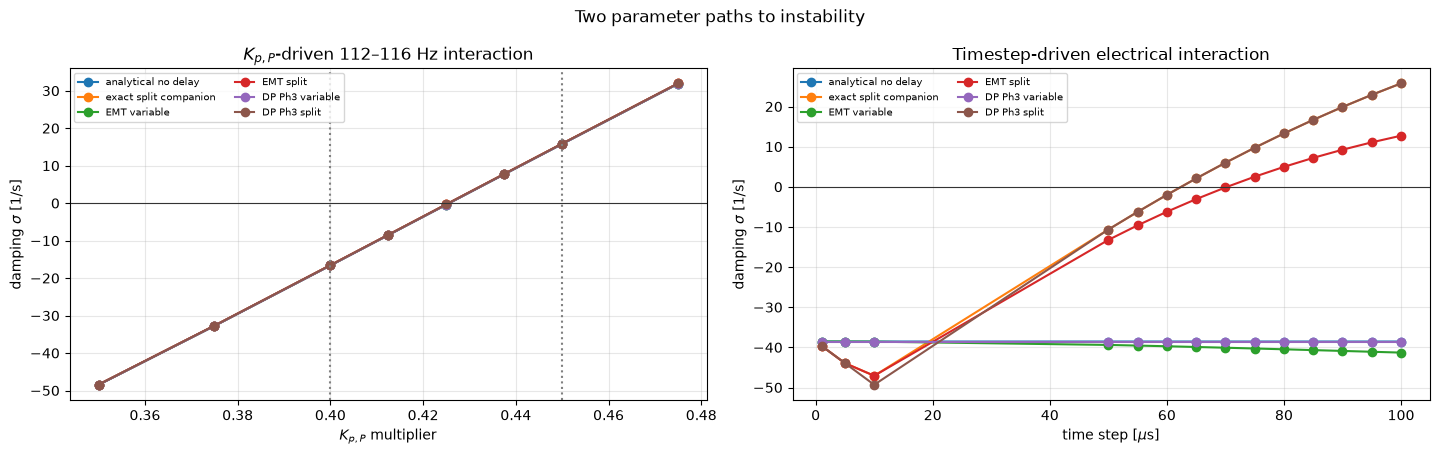

,model/reference,stable bracket [µs],unstable bracket [µs],linear crossing estimate [µs]
0,DP Ph3 split,60.0,65.0,62.45
1,EMT split,70.0,75.0,70.30
2,exact split companion,60.0,65.0,62.45


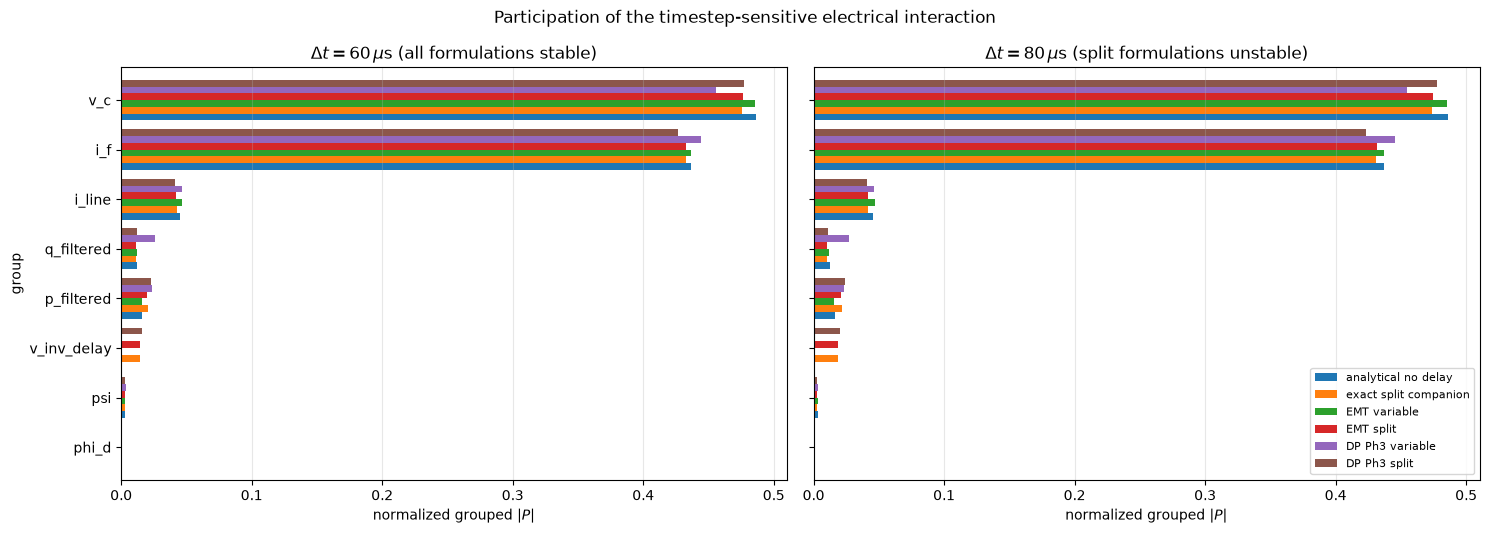

In [29]:
gain_records = []
for mult in sorted(eigenvalues.loc[eigenvalues.study == "kp_power_sweep",
                                   "kp_power_multiplier"].unique()):
    no_delay = mode_near("analytical no delay", 114.0, study="kp_power_sweep",
                         kp_power_multiplier=mult, frequency_window=(50, 300))
    delayed = mode_near("exact split companion", no_delay.lambda_imag/(2*np.pi),
                        study="kp_power_sweep", kp_power_multiplier=mult,
                        frequency_window=(50, 300))
    for model in model_order:
        ref = delayed if "split" in model else no_delay
        mode = ref if model in reference_models else nearest_lambda(
            finite_modes(rows_for(model, 1.0, "kp_power_sweep", modal_method(model), mult), True),
            ref.lambda_real, ref.lambda_imag)
        gain_records.append({"kp_power_multiplier": mult, "model": model,
                             "damping": mode.lambda_real,
                             "frequency_hz": mode.lambda_imag/(2*np.pi)})
gain_sweep = pd.DataFrame(gain_records)

def track_electrical_timestep_modes(maximum_dt_us=100.0):
    records = []
    steps = sorted(eigenvalues.loc[(eigenvalues.study == "time_step_sweep")
                                   & (eigenvalues.time_step_us <= maximum_dt_us),
                                   "time_step_us"].unique())
    for dt in steps:
        refs = {}
        for reference_name in ["analytical no delay", "exact split companion"]:
            candidates = finite_modes(rows_for(reference_name, dt), True)
            electrical = candidates[(candidates.lambda_imag > 2*np.pi*800.0)
                                    & (candidates.lambda_imag < 2*np.pi*1500.0)]
            refs[reference_name] = electrical.loc[electrical.lambda_real.idxmax()]
        # The full three-phase model contains 50 Hz-shifted copies of this
        # electrical interaction.  Select the least-damped copy at every step;
        # this is the stability-relevant branch envelope, not a claim that one
        # raw eigenvalue index remains invariant through sideband crossings.
        for model in model_order:
            ref = refs[matching_reference(model)] if model not in reference_models else refs[model]
            mode = ref if model in reference_models else nearest_z(
                finite_modes(rows_for(model, dt, method="one_step"), True), ref)
            records.append({"model": model, "time_step_us": dt,
                            "damping": mode.lambda_real,
                            "frequency_hz": mode.lambda_imag/(2*np.pi)})
    return pd.DataFrame(records)

tracked_timestep_mode = track_electrical_timestep_modes()
threshold_records = []
for model, rows in tracked_timestep_mode.groupby("model"):
    rows = rows.sort_values("time_step_us").reset_index(drop=True)
    crossing = rows[(rows.damping.shift(1) < 0) & (rows.damping >= 0)]
    if crossing.empty:
        continue
    upper = crossing.index[0]; lower = upper-1
    x0, y0 = rows.loc[lower, ["time_step_us", "damping"]]
    x1, y1 = rows.loc[upper, ["time_step_us", "damping"]]
    estimate = x0-y0*(x1-x0)/(y1-y0)
    threshold_records.append({"model/reference": model,
                              "stable bracket [µs]": x0,
                              "unstable bracket [µs]": x1,
                              "linear crossing estimate [µs]": estimate})
threshold_table = pd.DataFrame(threshold_records)
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))
for model in model_order:
    rows = gain_sweep[gain_sweep.model == model]
    axes[0].plot(rows.kp_power_multiplier, rows.damping, "o-",
                 color=colors[model], label=model)
axes[0].axhline(0, color="0.2", lw=0.8); axes[0].axvline(0.4, color="0.5", ls=":")
axes[0].axvline(0.45, color="0.5", ls=":")
axes[0].set(title=r"$K_{p,P}$-driven 112–116 Hz interaction",
            xlabel=r"$K_{p,P}$ multiplier", ylabel=r"damping $\sigma$ [1/s]")
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=7, ncol=2)
for model in tracked_timestep_mode.model.unique():
    rows = tracked_timestep_mode[tracked_timestep_mode.model == model]
    axes[1].plot(rows.time_step_us, rows.damping, "o-", color=colors[model], label=model)
axes[1].axhline(0, color="0.2", lw=0.8)
axes[1].set(title="Timestep-driven electrical interaction", xlabel=r"time step [$\mu$s]",
            ylabel=r"damping $\sigma$ [1/s]")
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=7, ncol=2)
fig.suptitle("Two parameter paths to instability")
fig.tight_layout(); plt.show()
display_numeric_table(threshold_table, precision=2)

participation_steps = [60.0, 80.0]
electrical_grouped_by_dt = {}
for participation_dt in participation_steps:
    electrical_participation = {}
    for model in model_order:
        target = tracked_timestep_mode[(tracked_timestep_mode.model == model)
                                       & np.isclose(tracked_timestep_mode.time_step_us, participation_dt)].iloc[0]
        electrical_participation[model] = grouped_participation(
            model, target.frequency_hz, participation_dt)
    electrical_grouped_by_dt[participation_dt] = pd.concat(
        electrical_participation, axis=1).fillna(0)

# Use the same state groups and horizontal scale so that the stable and
# unstable split cases can be compared directly.
combined_group_strength = pd.concat(
    electrical_grouped_by_dt.values(), axis=1).max(axis=1)
electrical_groups = combined_group_strength.nlargest(8).index
fig, axes = plt.subplots(1, 2, figsize=(15.0, 5.4), sharex=True, sharey=True)
case_labels = {60.0: "all formulations stable",
               80.0: "split formulations unstable"}
for ax, participation_dt in zip(axes, participation_steps):
    electrical_grouped_by_dt[participation_dt].loc[electrical_groups].iloc[::-1].plot(
        kind="barh", ax=ax, width=0.82,
        color=[colors[m] for m in model_order])
    ax.set_title(rf"$\Delta t={participation_dt:g}\,\mu$s ({case_labels[participation_dt]})")
    ax.set_xlabel(r"normalized grouped $|P|$")
    ax.grid(axis="x", alpha=0.3)
axes[0].set_ylabel("group")
axes[0].get_legend().remove()
axes[1].legend(fontsize=8, loc="lower right")
fig.suptitle("Participation of the timestep-sensitive electrical interaction")
fig.tight_layout(); plt.show()


### Scheduled disturbance and free response

At $t=0$, the balanced grid-voltage reference is increased by 0.1% for 0.5 ms and restored. Every formulation receives the same physical excitation from its common power-flow initialization. Separate small panels prevent coincident responses or a strongly growing case from hiding another model. The timestep comparison uses 60 and 80 µs, closer to the extracted transition than the retained wide-bracket 50 and 100 µs diagnostic cases.


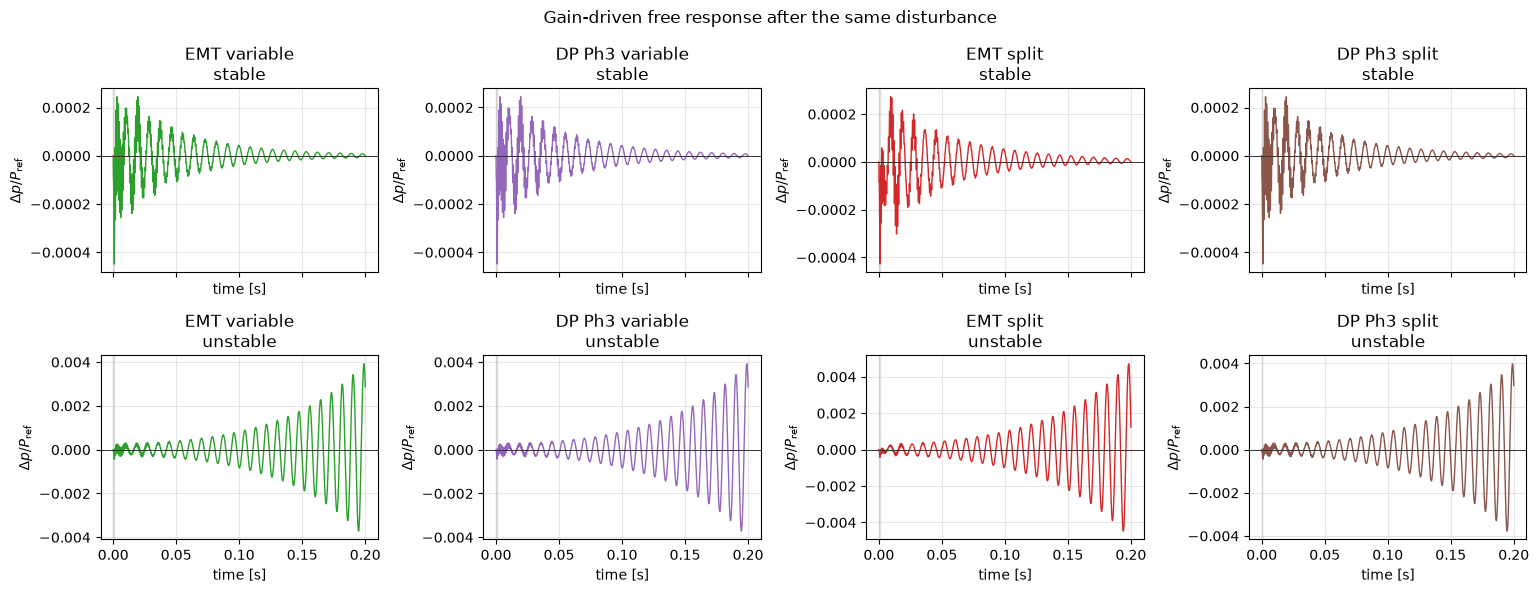

,case,model,extracted damping [1/s],fitted damping [1/s],extracted frequency [Hz],fitted frequency [Hz]
0,stable,EMT variable,-16.630,-16.046,112.121,112.113
1,stable,DP Ph3 variable,-16.629,-16.046,112.121,112.113
2,stable,EMT split,-16.560,-16.238,112.104,112.039
3,stable,DP Ph3 split,-16.563,-15.979,112.105,112.098
4,unstable,EMT variable,15.798,16.241,116.389,116.390
5,unstable,DP Ph3 variable,15.798,16.241,116.389,116.390
6,unstable,EMT split,15.876,16.167,116.370,116.330
7,unstable,DP Ph3 split,15.875,16.316,116.371,116.372


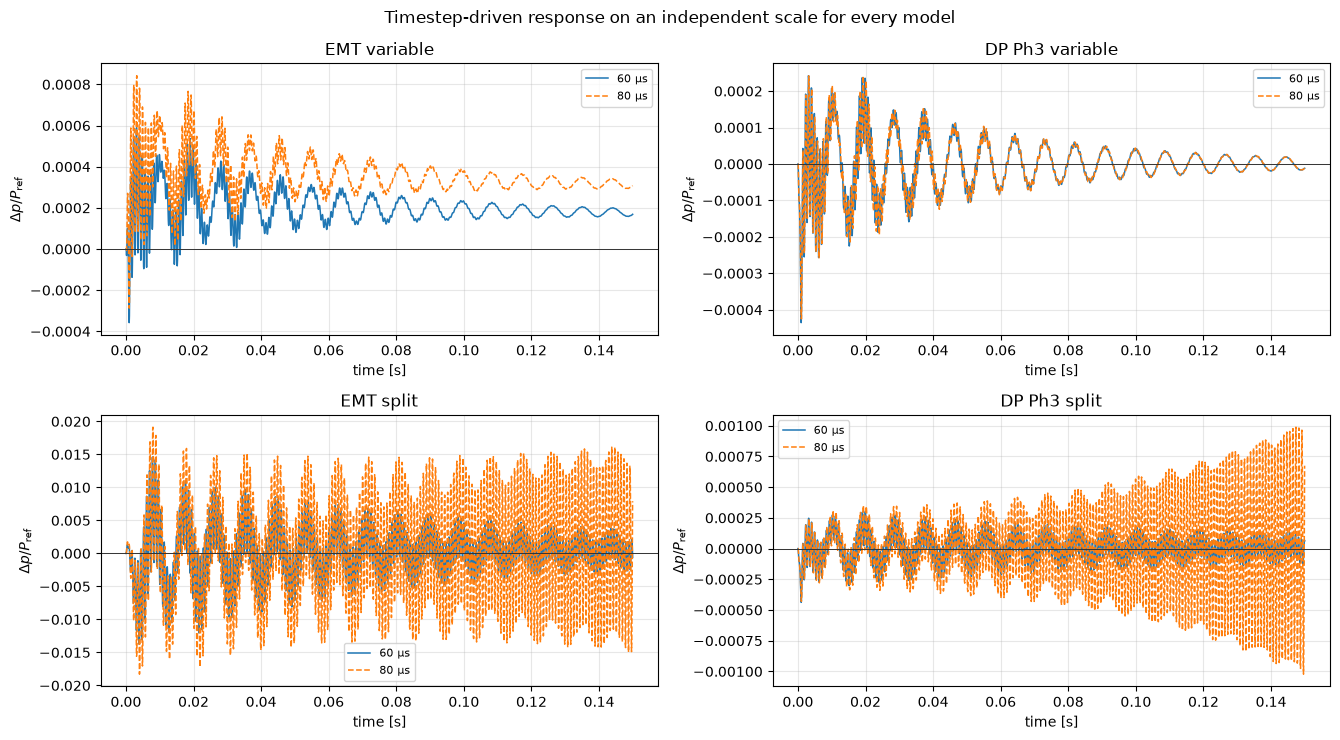

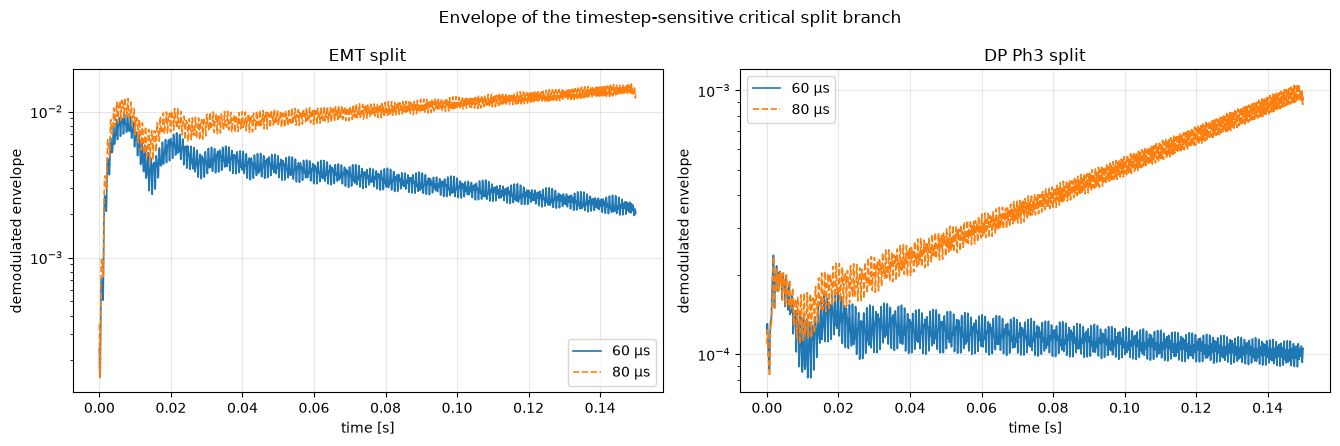

,model,time step [µs],extracted damping [1/s],fitted damping [1/s],extracted frequency [Hz],fitted frequency [Hz]
0,EMT split,60.0,-6.213,-6.684,1128.096,1128.096
1,EMT split,80.0,4.970,4.548,1112.021,1112.037
2,DP Ph3 split,60.0,-1.999,-1.983,1131.299,1131.284
3,DP Ph3 split,80.0,13.297,13.294,1117.121,1117.114


In [30]:
def load_time_case(case):
    path = Path(case.log_path)
    if not path.is_absolute(): path = build_dir/path
    data = pd.read_csv(path, skipinitialspace=True)
    time = data.iloc[:,0].to_numpy()
    p_column = next(c for c in data.columns if c == "p_inst" or c.startswith("p_inst_"))
    p_ref = float(parameter_table.loc["active_power_reference", "value"])
    signal = (data[p_column].to_numpy()-p_ref)/abs(p_ref)
    keep = np.isfinite(time) & np.isfinite(signal)
    return time[keep], signal[keep]

def envelope_and_fit(time, signal, predicted_frequency, start, end, smoothing):
    dt = np.median(np.diff(time)); samples = max(5, int(round(smoothing/dt)))
    baseband = signal*np.exp(-2j*np.pi*predicted_frequency*time)
    smooth = (pd.Series(baseband.real).rolling(samples, center=True, min_periods=samples//2).mean().to_numpy()
              + 1j*pd.Series(baseband.imag).rolling(samples, center=True, min_periods=samples//2).mean().to_numpy())
    envelope = 2*np.abs(smooth); phase = np.full(len(smooth), np.nan)
    valid = np.isfinite(smooth.real) & np.isfinite(smooth.imag)
    phase[valid] = np.unwrap(np.angle(smooth[valid]))
    fit = (time > start) & (time < end) & np.isfinite(envelope) & np.isfinite(phase) & (envelope > 1e-12)
    if fit.sum() < 20: return envelope, np.nan, np.nan, fit
    damping = np.polyfit(time[fit], np.log(envelope[fit]), 1)[0]
    frequency = predicted_frequency + np.polyfit(time[fit], phase[fit], 1)[0]/(2*np.pi)
    return envelope, damping, frequency, fit

if time_manifest.empty:
    print("No time-domain cases. Run the executable with --time-domain, then rerun this notebook.")
else:
    plotted_models = ["EMT variable", "DP Ph3 variable", "EMT split", "DP Ph3 split"]
    fig, axes = plt.subplots(2, 4, figsize=(15.5, 6.0), sharex=True)
    fit_records = []
    for row, case_name in enumerate(["stable", "unstable"]):
        for col, model in enumerate(plotted_models):
            ax = axes[row,col]
            cases = time_manifest[(time_manifest.stability_case == case_name)
                                  & (time_manifest.model == model)
                                  & np.isclose(time_manifest.time_step_us, 1.0)]
            for case in cases.itertuples():
                time, signal = load_time_case(case); ax.plot(time, signal, color=colors[model], lw=1)
                pulse_end = case.perturbation_time_s+case.perturbation_duration_s
                ax.axvspan(case.perturbation_time_s, pulse_end, color="0.88")
                predicted = mode_near(model, 114.0, 1.0, f"stability_{case_name}",
                                      frequency_window=(50,300))
                envelope, damping, frequency, fit = envelope_and_fit(
                    time, signal, predicted.lambda_imag/(2*np.pi), pulse_end+0.006,
                    time.max()-0.02, 0.015)
                fit_records.append({"case": case_name, "model": model,
                                    "extracted damping [1/s]": predicted.lambda_real,
                                    "fitted damping [1/s]": damping,
                                    "extracted frequency [Hz]": predicted.lambda_imag/(2*np.pi),
                                    "fitted frequency [Hz]": frequency})
            ax.axhline(0, color="0.2", lw=.7); ax.grid(alpha=.3)
            ax.set(title=f"{model}\n{case_name}", xlabel="time [s]", ylabel=r"$\Delta p/P_\mathrm{ref}$")
    fig.suptitle("Gain-driven free response after the same disturbance")
    fig.tight_layout(); plt.show()
    display_numeric_table(pd.DataFrame(fit_records), precision=3)

    fig, axes = plt.subplots(2, 2, figsize=(13.5, 7.5))
    for ax, model in zip(axes.flat, plotted_models):
        for case_name, dt, style, color in [("near_transition_stable",60.0,"-","tab:blue"),
                                             ("near_transition_unstable",80.0,"--","tab:orange")]:
            cases = time_manifest[(time_manifest.model == model)
                                  & (time_manifest.stability_case == case_name)
                                  & np.isclose(time_manifest.time_step_us, dt)]
            for case in cases.itertuples():
                time, signal = load_time_case(case)
                ax.plot(time, signal, style, color=color, lw=1.1, label=f"{dt:g} µs")
        ax.axhline(0,color="0.2",lw=.7); ax.grid(alpha=.3); ax.legend(fontsize=8)
        ax.set(title=model, xlabel="time [s]", ylabel=r"$\Delta p/P_\mathrm{ref}$")
    fig.suptitle("Timestep-driven response on an independent scale for every model")
    fig.tight_layout(); plt.show()

    coarse_records = []
    fig, axes = plt.subplots(1,2,figsize=(13.5,4.5))
    for ax, model in zip(axes,["EMT split","DP Ph3 split"]):
        for case_name, dt, style, color in [("near_transition_stable",60.0,"-","tab:blue"),
                                             ("near_transition_unstable",80.0,"--","tab:orange")]:
            cases = time_manifest[(time_manifest.model == model)
                                  & (time_manifest.stability_case == case_name)
                                  & np.isclose(time_manifest.time_step_us,dt)]
            if cases.empty: continue
            case = next(cases.itertuples()); time, signal = load_time_case(case)
            predicted = tracked_timestep_mode[(tracked_timestep_mode.model==model)
                                              & np.isclose(tracked_timestep_mode.time_step_us,dt)].iloc[0]
            envelope, damping, frequency, fit = envelope_and_fit(
                time, signal, predicted.frequency_hz, 0.02,
                time.max()-0.02, 0.002)
            ax.semilogy(time,envelope,style,color=color,lw=1.2,label=f"{dt:g} µs")
            coarse_records.append({"model":model,"time step [µs]":dt,
                                   "extracted damping [1/s]":predicted.damping,
                                   "fitted damping [1/s]":damping,
                                   "extracted frequency [Hz]":predicted.frequency_hz,
                                   "fitted frequency [Hz]":frequency})
        ax.grid(alpha=.3); ax.legend(); ax.set(title=model,xlabel="time [s]",ylabel="demodulated envelope")
    fig.suptitle("Envelope of the timestep-sensitive critical split branch")
    fig.tight_layout(); plt.show()
    display_numeric_table(pd.DataFrame(coarse_records), precision=3)


**Study 3 claim.** The extracted models predict stable and unstable responses on both sides of the independently varied $K_{p,P}$ and split-model timestep boundaries, together with the dominant modal frequency and approximate damping. Quantitative damping fits are used as supporting evidence rather than exact equality because a finite physical pulse excites multiple modes and residual initialization components.

## Conclusions

1. The benchmark is a 3.3 kV, 12 MVA converter connected to a weak Thevenin grid; parameters are defined in per unit and converted centrally to SI.
2. All formulations share the same power-flow initialization and physical disturbance.
3. At small timestep, extracted critical modes and participation agree with separately assembled, component-wise formulation-specific references.
4. The Study 3 controller trajectory varies one coefficient only: the outer power-loop proportional gain.
5. The 112–116 Hz controller/grid interaction crosses the imaginary axis consistently in analytical, EMT, and DP results.
6. Increasing timestep destabilizes a separate split-model electrical branch near 1.1 kHz.
7. Global spectrum distances are not used as validation metrics because reduced $dq0$ references omit full three-phase sideband copies and split models contain very fast numerical delay roots.
8. These studies validate the extraction and modal-analysis workflow for the selected weak-grid benchmark; broader robustness across converter ratings, grid strengths, operating points, and controller designs is outside the present scope.
